In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 120

np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=1,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=41,
    hypercube=False,
    class_sep=10
)

X.shape, y.shape

((100, 2), (100,))

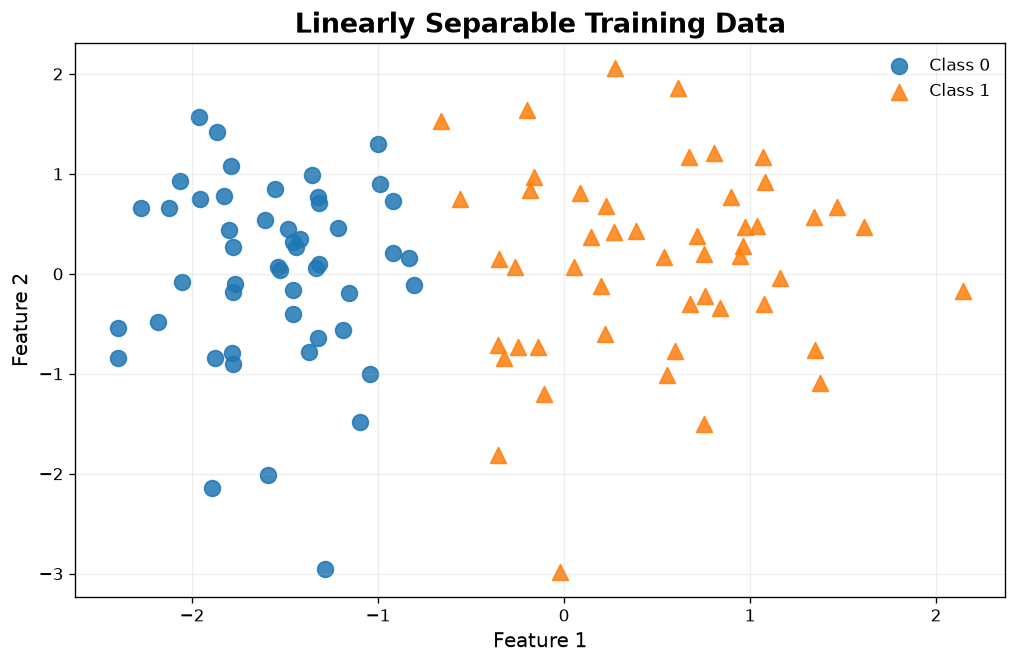

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    s=90,
    alpha=0.85,
    label="Class 0"
)

ax.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    s=90,
    alpha=0.85,
    marker="^",
    label="Class 1"
)

ax.set_title("Linearly Separable Training Data")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()

In [4]:
def step(z):
    return np.where(z > 0, 1, 0)

def predict(X, weights):
    X_bias = np.insert(X, 0, 1, axis=1)
    return step(X_bias @ weights)

In [5]:
def perceptron(X, y, learning_rate=0.1, epochs=1000, seed=42):
    rng = np.random.default_rng(seed)
    X_bias = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X_bias.shape[1])
    errors = []
    weight_history = []

    for _ in range(epochs):
        mistakes = 0
        indices = rng.permutation(len(X_bias))

        for j in indices:
            y_hat = step(X_bias[j] @ weights)
            update = learning_rate * (y[j] - y_hat)
            weights = weights + update * X_bias[j]
            mistakes += int(update != 0)

        errors.append(mistakes)
        weight_history.append(weights.copy())

        if mistakes == 0:
            break

    return weights, np.array(errors), np.array(weight_history)

In [6]:
weights, errors, weight_history = perceptron(
    X,
    y,
    learning_rate=0.1,
    epochs=1000,
    seed=42
)

intercept = weights[0]
coef = weights[1:]

print("Intercept:", intercept)
print("Coefficients:", coef)
print("Training epochs:", len(errors))
print("Final mistakes:", errors[-1])

Intercept: 1.0
Coefficients: [1.31913895 0.09502172]
Training epochs: 2
Final mistakes: 0


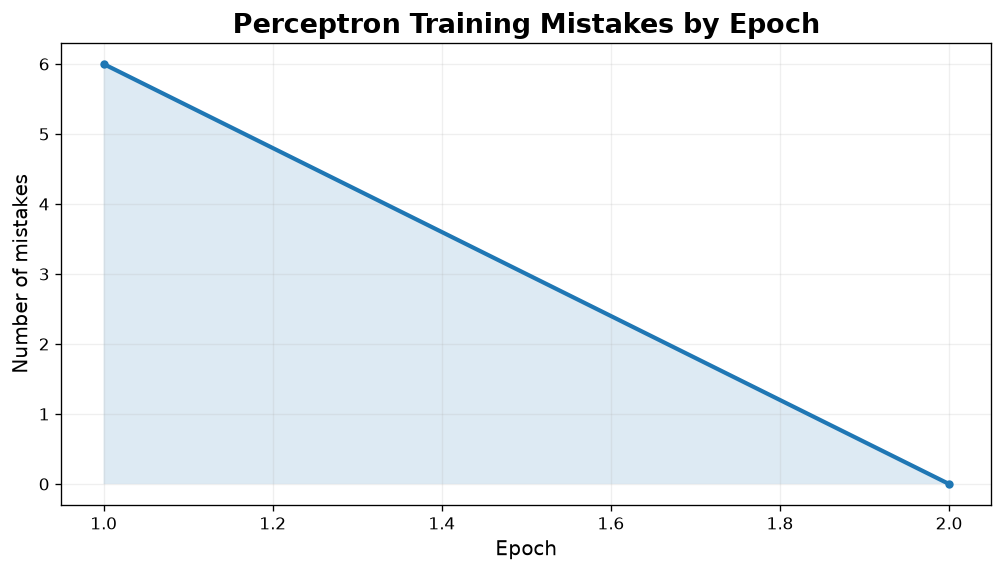

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    np.arange(1, len(errors) + 1),
    errors,
    linewidth=2.5,
    marker="o",
    markersize=4
)

ax.fill_between(
    np.arange(1, len(errors) + 1),
    errors,
    alpha=0.15
)

ax.set_title("Perceptron Training Mistakes by Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Number of mistakes")
ax.grid(alpha=0.2)

plt.show()

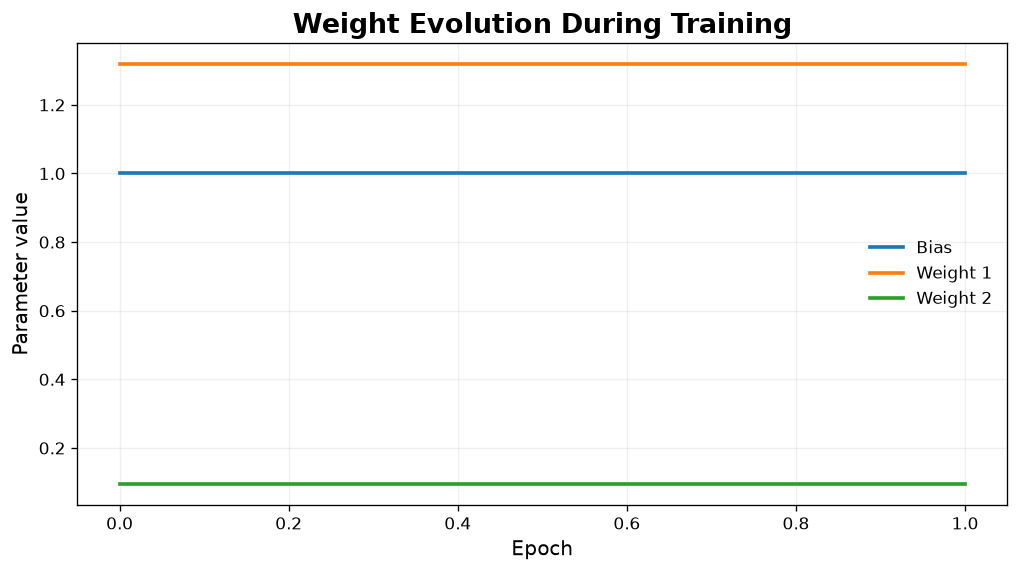

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(weight_history[:, 0], linewidth=2.2, label="Bias")
ax.plot(weight_history[:, 1], linewidth=2.2, label="Weight 1")
ax.plot(weight_history[:, 2], linewidth=2.2, label="Weight 2")

ax.set_title("Weight Evolution During Training")
ax.set_xlabel("Epoch")
ax.set_ylabel("Parameter value")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.show()

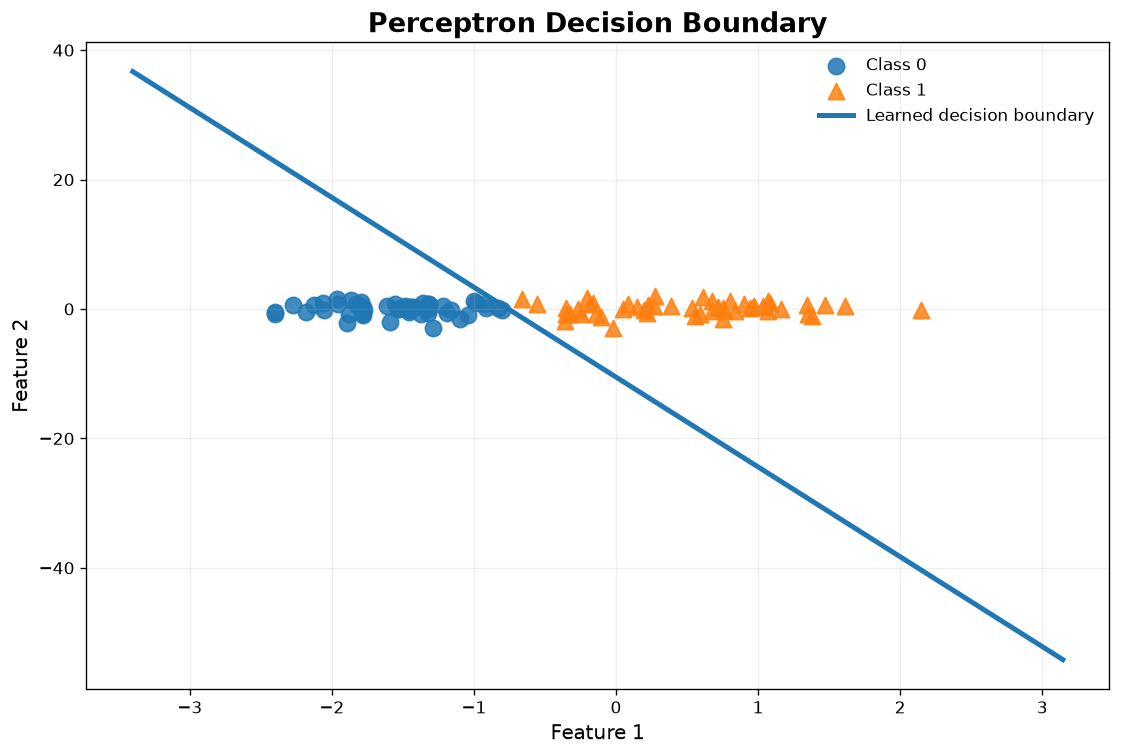

In [9]:
x_line = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
y_line = -(coef[0] / coef[1]) * x_line - (intercept / coef[1])

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    s=95,
    alpha=0.85,
    label="Class 0"
)

ax.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    s=95,
    alpha=0.85,
    marker="^",
    label="Class 1"
)

ax.plot(
    x_line,
    y_line,
    linewidth=3,
    label="Learned decision boundary"
)

ax.set_title("Perceptron Decision Boundary")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.show()

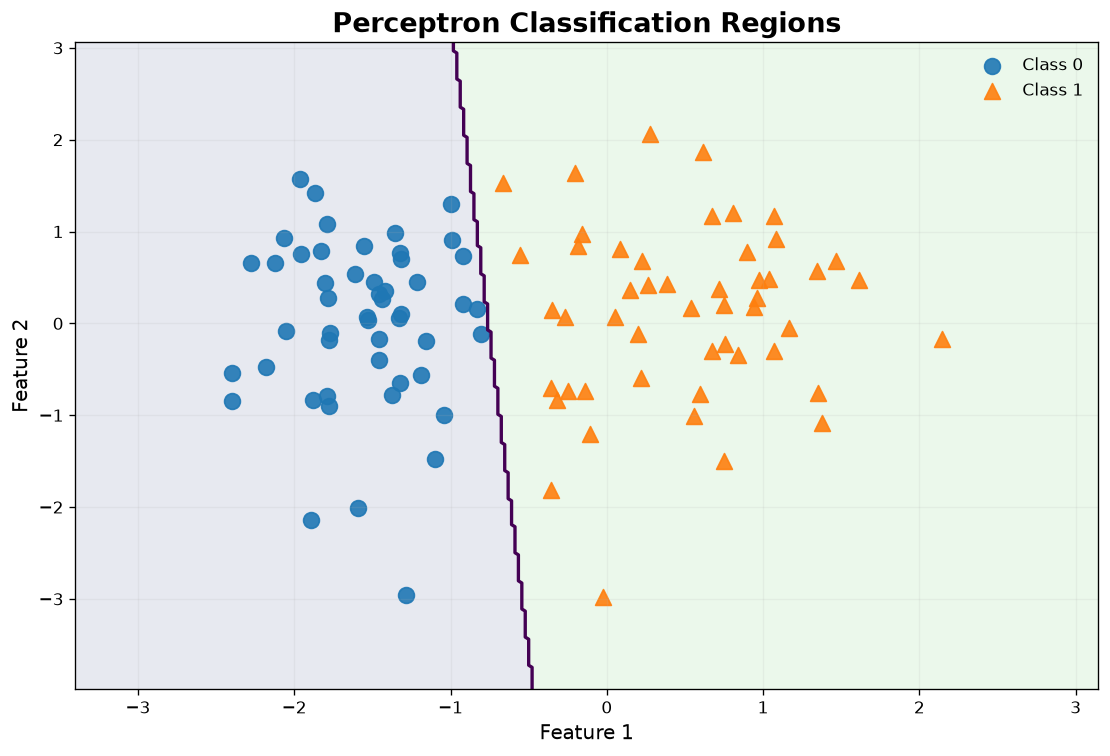

In [10]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
zz = predict(grid, weights).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(11, 7))

ax.contourf(
    xx,
    yy,
    zz,
    levels=[-0.5, 0.5, 1.5],
    alpha=0.12
)

ax.contour(
    xx,
    yy,
    zz,
    levels=[0.5],
    linewidths=2
)

ax.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    s=90,
    alpha=0.9,
    label="Class 0"
)

ax.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    s=90,
    alpha=0.9,
    marker="^",
    label="Class 1"
)

ax.set_title("Perceptron Classification Regions")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(alpha=0.15)
ax.legend(frameon=False)

plt.show()

In [11]:
y_pred = predict(X, weights)
accuracy = np.mean(y_pred == y)

print("Accuracy:", accuracy)
print("Correct predictions:", np.sum(y_pred == y))
print("Incorrect predictions:", np.sum(y_pred != y))

Accuracy: 1.0
Correct predictions: 100
Incorrect predictions: 0


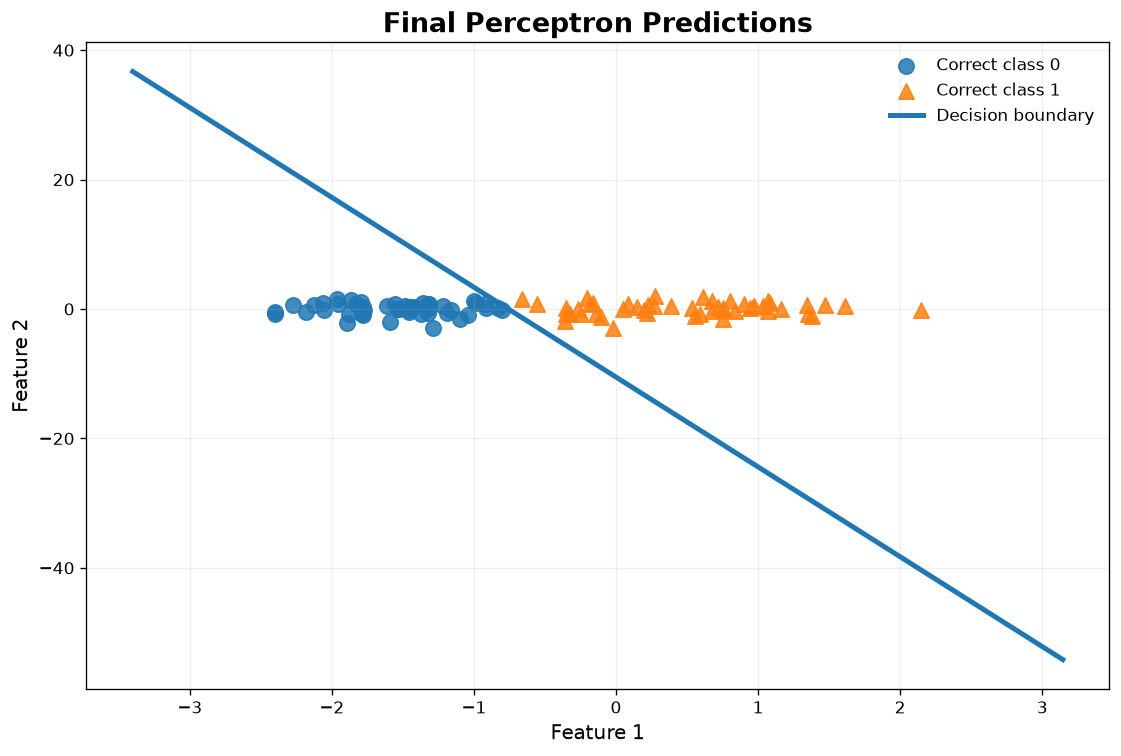

In [12]:
correct = y_pred == y
incorrect = ~correct

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    X[correct & (y == 0), 0],
    X[correct & (y == 0), 1],
    s=85,
    alpha=0.85,
    label="Correct class 0"
)

ax.scatter(
    X[correct & (y == 1), 0],
    X[correct & (y == 1), 1],
    s=85,
    alpha=0.85,
    marker="^",
    label="Correct class 1"
)

if np.any(incorrect):
    ax.scatter(
        X[incorrect, 0],
        X[incorrect, 1],
        s=180,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="Misclassified"
    )

ax.plot(
    x_line,
    y_line,
    linewidth=3,
    label="Decision boundary"
)

ax.set_title("Final Perceptron Predictions")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.show()

In [13]:
new_points = np.array([
    [0.0, -1.0],
    [0.0, 1.0],
    [1.0, -0.5],
    [1.0, 1.0]
])

new_predictions = predict(new_points, weights)

for point, prediction in zip(new_points, new_predictions):
    print(f"Point {point} -> Class {prediction}")

Point [ 0. -1.] -> Class 1
Point [0. 1.] -> Class 1
Point [ 1.  -0.5] -> Class 1
Point [1. 1.] -> Class 1
